In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
df = pd.read_csv(os.path.join("data", "Project1_DB_heart_disease.csv"))
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    int64  
 1   sex                  303 non-null    int64  
 2   chest_pain_type      303 non-null    int64  
 3   resting_bp           303 non-null    int64  
 4   cholesterol          303 non-null    int64  
 5   fasting_blood_sugar  303 non-null    int64  
 6   resting_ecg          303 non-null    int64  
 7   max_heart_rate       303 non-null    int64  
 8   exercise_angina      303 non-null    int64  
 9   st_depression        303 non-null    float64
 10  target               303 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 26.2 KB


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["age", "resting_bp", "cholesterol", "max_heart_rate", "st_depression"]
cat_cols = ["chest_pain_type", "resting_ecg"]  

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")


In [4]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,target
0,67,1,0,134,188,0,0,163,1,2.9,0
1,57,1,2,126,157,1,2,153,1,2.2,1
2,43,0,3,112,237,0,2,133,0,0.5,1
3,71,1,3,114,228,0,2,156,1,1.5,1
4,36,1,1,137,170,0,0,163,0,0.6,0


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

# prep = dein ColumnTransformer von vorhin
models = {
    "KNN":          make_pipeline(prep, KNeighborsClassifier(n_neighbors=5)),
    "SVM":          make_pipeline(prep, SVC(probability=True)),
    "LogReg":       make_pipeline(prep, LogisticRegression(max_iter=1000)),
    "RandomForest": make_pipeline(prep, RandomForestClassifier(random_state=42)),
    "DecisionTree":     make_pipeline(prep, DecisionTreeClassifier(random_state=42)),
    "GradientBoosting": make_pipeline(prep, GradientBoostingClassifier(random_state=42)),
    "Baseline (dummy)": make_pipeline(prep, DummyClassifier(strategy="most_frequent")),
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, model in models.items():
    cv = cross_validate(model, X, y, cv=5, scoring=scoring)
    rows.append({"model": name, **{m: cv[f"test_{m}"].mean() for m in scoring}})

results = pd.DataFrame(rows).set_index("model").round(3)
print(results)

                  accuracy  precision  recall     f1  roc_auc
model                                                        
KNN                  0.654      0.697   0.640  0.666    0.707
SVM                  0.730      0.763   0.732  0.743    0.804
LogReg               0.726      0.736   0.769  0.750    0.800
RandomForest         0.703      0.721   0.744  0.730    0.779
DecisionTree         0.654      0.684   0.683  0.680    0.651
GradientBoosting     0.690      0.712   0.726  0.716    0.745
Baseline (dummy)     0.541      0.541   1.000  0.702    0.500


                  accuracy  precision  recall     f1  roc_auc  \
model                                                           
KNN                  0.654      0.697   0.640  0.666    0.707   
SVM                  0.730      0.763   0.732  0.743    0.804   
LogReg               0.726      0.736   0.769  0.750    0.800   
RandomForest         0.703      0.721   0.744  0.730    0.779   
DecisionTree         0.654      0.684   0.683  0.680    0.651   
GradientBoosting     0.690      0.712   0.726  0.716    0.745   
Baseline (dummy)     0.541      0.541   1.000  0.702    0.500   

                                                   confusion_matrix  
model                                                                
KNN               <sklearn.metrics._plot.confusion_matrix.Confus...  
SVM               <sklearn.metrics._plot.confusion_matrix.Confus...  
LogReg            <sklearn.metrics._plot.confusion_matrix.Confus...  
RandomForest      <sklearn.metrics._plot.confusion_matrix.Confus

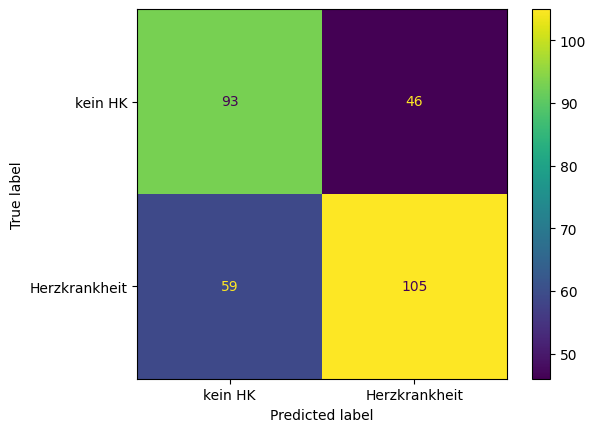

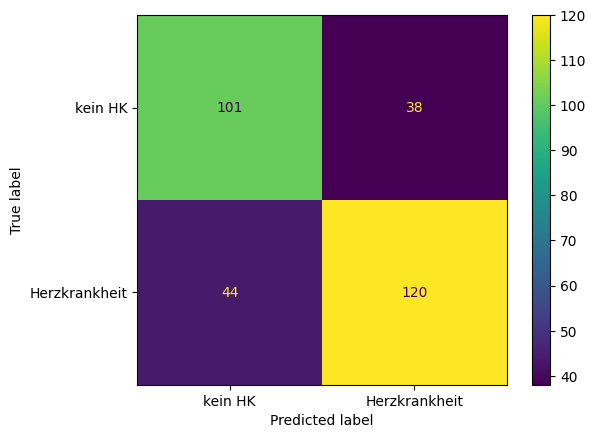

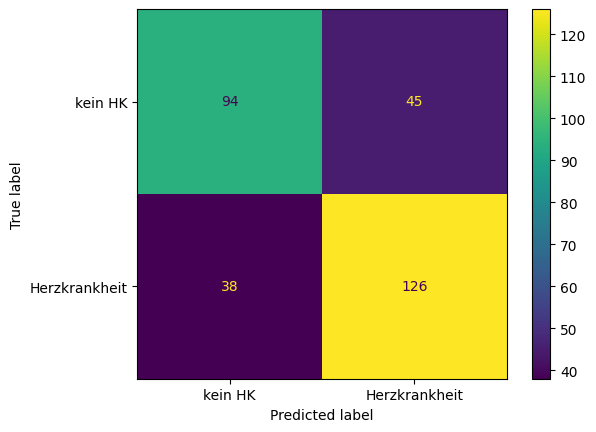

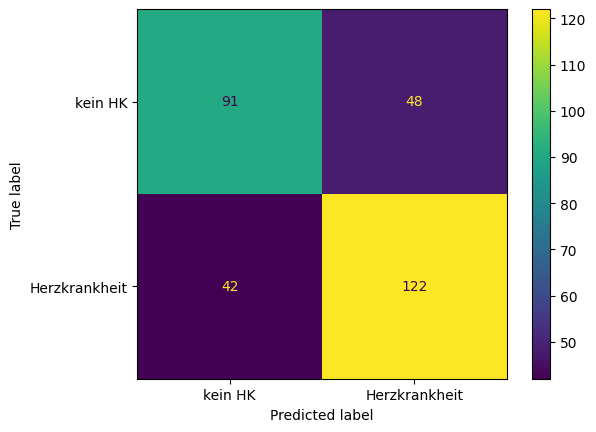

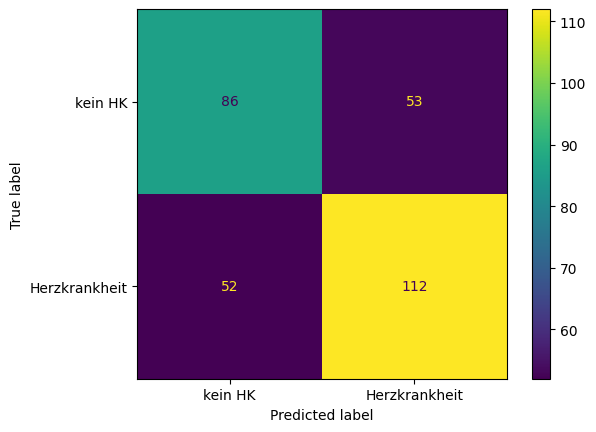

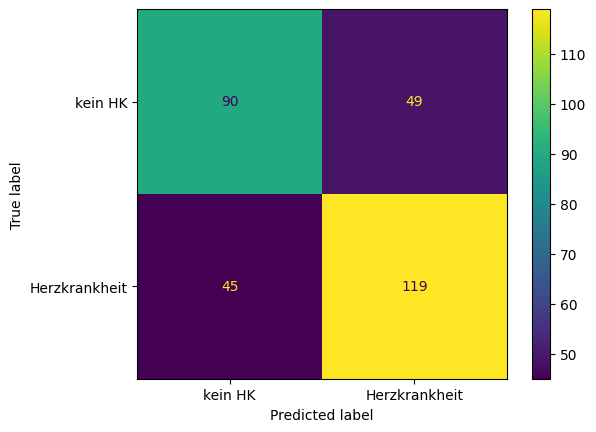

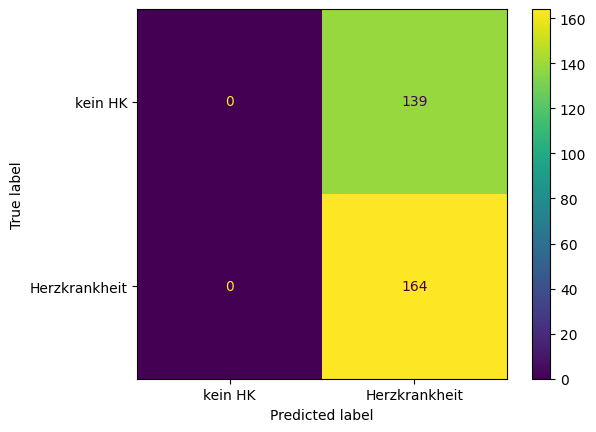

In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrices = []
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=5)
    disp = ConfusionMatrixDisplay.from_predictions(
        y, y_pred, display_labels=["kein HK", "Herzkrankheit"])
    confusion_matrices.append(disp)

results["confusion_matrix"] = confusion_matrices
print(results)

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_pipe = make_pipeline(prep, SVC(probability=True))

param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"],
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("best params:", grid_search.best_params_)
print("best cv roc_auc:", round(grid_search.best_score_, 3))
print("test roc_auc:", round(grid_search.score(X_test, y_test), 3))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


ValueError: Invalid parameter 'randomforestclassifier' for estimator Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'resting_bp',
                                                   'cholesterol',
                                                   'max_heart_rate',
                                                   'st_depression']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['chest_pain_type',
                                                   'resting_ecg'])])),
                ('svc', SVC(probability=True))]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].